# Chapter 22 — Natural Numbers

> **Prerequisites:** ch021 (The History of Numbers)
> 
> **You will learn:**
> - The Peano axioms: what it means to *define* the natural numbers from scratch
> - Induction as a computational process
> - Summation formulas and their derivation
> - How iteration and recursion mirror the successor function
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

The natural numbers $\{0, 1, 2, 3, \ldots\}$ are the first number system — the one built into human intuition from childhood. But "intuition" is not a mathematical definition. Giuseppe Peano gave a rigorous definition in 1889 using five axioms.

The key idea: you do not need to *explain* what a natural number is — you only need to define the rules they follow. The rules determine everything.

**Common misconception:** "0 is not a natural number." Depends on convention. In computer science and most modern mathematics, 0 ∈ ℕ. In some older traditions, ℕ starts at 1. This book uses 0 ∈ ℕ.

**Another misconception:** "Mathematical induction is proof by example." It is not. Induction proves a statement for *all* natural numbers simultaneously, via the successor structure.

## 2. Intuition & Mental Models

**Think of ℕ as a program:** There is a starting value (0), and a `next()` function (the successor). Every natural number is reachable by calling `next()` enough times from 0. Nothing else is in ℕ.

```
0 → next → 1 → next → 2 → next → 3 → ...
```

**Induction as loop invariant:** Mathematical induction is exactly the reasoning behind loop correctness proofs. You prove a property holds at step 0, and you prove that if it holds at step $n$ it holds at step $n+1$. Then it holds for all steps — just as a loop invariant guarantees correctness for all iterations.

**Recursion mirrors the Peano axioms:** A recursive function has a base case (0) and a recursive case (n+1 defined in terms of n). This is not a coincidence — it is the same structure.

*(Recall from ch006 — Discrete vs Continuous Thinking: natural numbers are the paradigmatic discrete structure.)*

## 3. Visualization

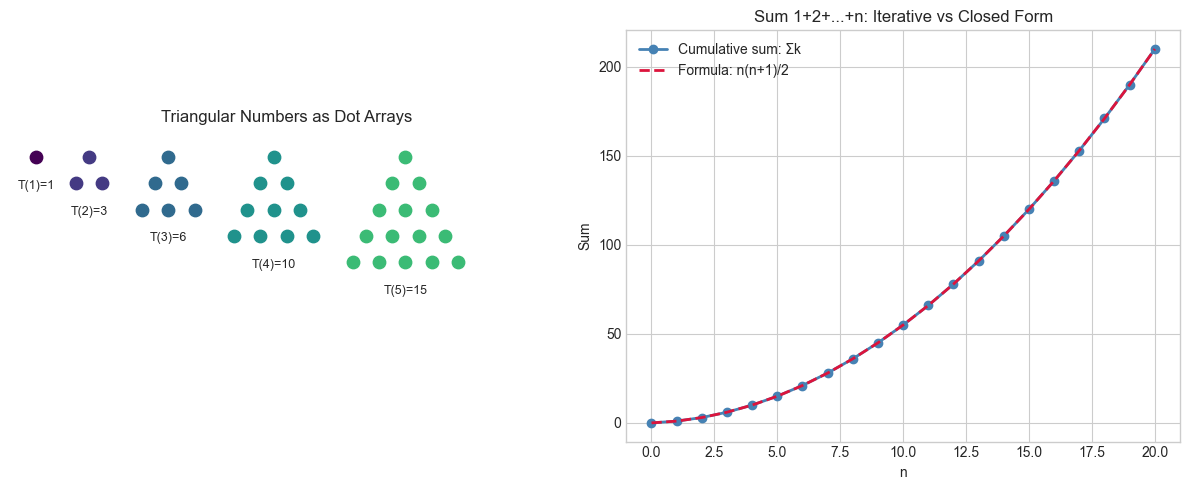

Iterative and formula agree for all n in [0, 20].


In [1]:
# --- Visualization: Triangular numbers and the sum 1+2+...+n ---
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.style.use('seaborn-v0_8-whitegrid')

def triangular(n):
    """Return the nth triangular number T(n) = n*(n+1)/2."""
    return n * (n + 1) // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: triangular numbers as dot arrangements
ax = axes[0]
ax.set_aspect('equal')
ax.set_title('Triangular Numbers as Dot Arrays')
colors = plt.cm.viridis(np.linspace(0, 0.85, 6))
x_offset = 0
for n in range(1, 6):
    for row in range(n):
        for col in range(row + 1):
            ax.scatter(x_offset + col - row/2, -row, color=colors[n-1], s=80, zorder=3)
    ax.text(x_offset, -(n-1) - 1.2, f'T({n})={triangular(n)}', ha='center', fontsize=9)
    x_offset += n + 1
ax.set_xlim(-1, x_offset)
ax.set_ylim(-7, 1)
ax.axis('off')

# Plot 2: cumulative sums vs formula
ax = axes[1]
N_MAX = 20
ns = np.arange(0, N_MAX + 1)
cumsum = np.cumsum(ns)              # iterative
formula = ns * (ns + 1) // 2       # closed form

ax.plot(ns, cumsum, 'o-', label='Cumulative sum: Σk', color='steelblue', linewidth=2)
ax.plot(ns, formula, '--', label='Formula: n(n+1)/2', color='crimson', linewidth=2)
ax.set_xlabel('n')
ax.set_ylabel('Sum')
ax.set_title('Sum 1+2+...+n: Iterative vs Closed Form')
ax.legend()

plt.tight_layout()
plt.show()

# Verify they match
assert np.array_equal(cumsum, formula), "Mismatch!"
print("Iterative and formula agree for all n in [0, 20].")

## 4. Mathematical Formulation

**Peano Axioms (informal version):**
1. $0 \in \mathbb{N}$
2. Every $n \in \mathbb{N}$ has a successor $S(n) \in \mathbb{N}$
3. $0$ is not the successor of any natural number
4. If $S(m) = S(n)$ then $m = n$ (successor is injective)
5. **Induction axiom:** If a property holds for 0 and is preserved by the successor, it holds for all natural numbers.

**Gauss's sum formula:**
$$\sum_{k=1}^{n} k = \frac{n(n+1)}{2}$$

**Proof by induction:**
- Base: $n=1$: $1 = 1(2)/2 = 1$. ✓
- Step: Assume true for $n$. Then $\sum_{k=1}^{n+1} k = \frac{n(n+1)}{2} + (n+1) = \frac{(n+1)(n+2)}{2}$. ✓

**Sum of squares:**
$$\sum_{k=1}^{n} k^2 = \frac{n(n+1)(2n+1)}{6}$$

## 5. Python Implementation

In [2]:
# --- Implementation: Natural number arithmetic via Peano-style recursion ---

def peano_add(m, n):
    """
    Add two natural numbers using only the successor and predecessor operations.
    This directly mirrors the Peano recursive definition of addition:
      add(m, 0) = m
      add(m, S(n)) = S(add(m, n))

    Args:
        m: non-negative int
        n: non-negative int

    Returns:
        int: m + n
    """
    if n == 0:
        return m
    return peano_add(m, n - 1) + 1  # S(add(m, n-1))


def peano_multiply(m, n):
    """
    Multiply two natural numbers using Peano recursion:
      mul(m, 0) = 0
      mul(m, S(n)) = mul(m, n) + m

    Args:
        m: non-negative int
        n: non-negative int

    Returns:
        int: m * n
    """
    if n == 0:
        return 0
    return peano_multiply(m, n - 1) + m


def sum_natural(n):
    """
    Compute 1 + 2 + ... + n using the closed-form Gauss formula.

    Args:
        n: non-negative int

    Returns:
        int: n*(n+1)//2
    """
    return n * (n + 1) // 2


# Validation
import sys
sys.setrecursionlimit(500)

print("Peano addition tests:")
for a, b in [(3, 4), (0, 7), (10, 5)]:
    result = peano_add(a, b)
    assert result == a + b
    print(f"  peano_add({a}, {b}) = {result}  ✓")

print("\nPeano multiplication tests:")
for a, b in [(3, 4), (0, 7), (5, 5)]:
    result = peano_multiply(a, b)
    assert result == a * b
    print(f"  peano_multiply({a}, {b}) = {result}  ✓")

print("\nGauss sum tests:")
for n in [1, 5, 10, 100]:
    brute = sum(range(n + 1))
    formula = sum_natural(n)
    assert brute == formula
    print(f"  sum_natural({n}) = {formula}  ✓")

Peano addition tests:
  peano_add(3, 4) = 7  ✓
  peano_add(0, 7) = 7  ✓
  peano_add(10, 5) = 15  ✓

Peano multiplication tests:
  peano_multiply(3, 4) = 12  ✓
  peano_multiply(0, 7) = 0  ✓
  peano_multiply(5, 5) = 25  ✓

Gauss sum tests:
  sum_natural(1) = 1  ✓
  sum_natural(5) = 15  ✓
  sum_natural(10) = 55  ✓
  sum_natural(100) = 5050  ✓


## 6. Experiments

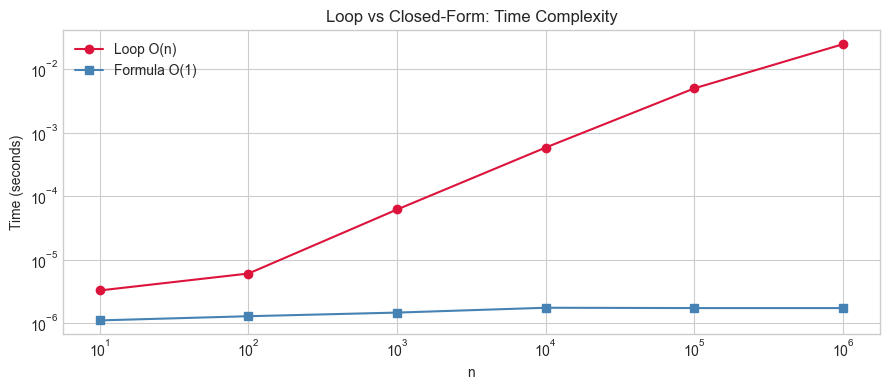

In [3]:
# --- Experiment 1: Performance of loop vs formula ---
# Hypothesis: closed-form formula is O(1); loop is O(n); gap grows with n
# Try changing: the values in ns

import time
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

ns = [10, 100, 1_000, 10_000, 100_000, 1_000_000]  # <-- modify this
loop_times = []
formula_times = []

REPS = 5  # average over REPS trials

for n in ns:
    t0 = time.perf_counter()
    for _ in range(REPS):
        _ = sum(range(n + 1))
    loop_times.append((time.perf_counter() - t0) / REPS)

    t0 = time.perf_counter()
    for _ in range(REPS):
        _ = n * (n + 1) // 2
    formula_times.append((time.perf_counter() - t0) / REPS)

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(ns, loop_times, 'o-', label='Loop O(n)', color='crimson')
ax.loglog(ns, formula_times, 's-', label='Formula O(1)', color='steelblue')
ax.set_xlabel('n')
ax.set_ylabel('Time (seconds)')
ax.set_title('Loop vs Closed-Form: Time Complexity')
ax.legend()
plt.tight_layout()
plt.show()

In [4]:
# --- Experiment 2: Figurate numbers generalize triangular numbers ---
# Hypothesis: square, pentagonal numbers follow the same recursive pattern
# Try changing: sides (3=triangular, 4=square, 5=pentagonal, 6=hexagonal)

SIDES = 5  # <-- modify this (try 3, 4, 5, 6)

def figurate(n, s):
    """Return nth s-gonal number."""
    return n * ((s - 2) * n - (s - 4)) // 2

ns = range(1, 15)
vals = [figurate(n, SIDES) for n in ns]

print(f"First 14 {SIDES}-gonal numbers: {vals}")
print(f"Differences: {[vals[i+1]-vals[i] for i in range(len(vals)-1)]}")

First 14 5-gonal numbers: [1, 5, 12, 22, 35, 51, 70, 92, 117, 145, 176, 210, 247, 287]
Differences: [4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40]


## 7. Exercises

**Easy 1.** Compute $\sum_{k=1}^{50} k$ using both the loop and the Gauss formula. Verify they agree. *(Expected: 1275)*

**Easy 2.** Verify the sum-of-squares formula $\sum_{k=1}^{n} k^2 = n(n+1)(2n+1)/6$ for $n = 1, 2, \ldots, 20$ by comparing to a brute-force loop.

**Medium 1.** Implement `fibonacci(n)` using the recursive Peano-style definition (base cases 0 and 1, recursive case $F(n) = F(n-1) + F(n-2)$). Then implement a memoized version. Compare the number of function calls for each.

**Medium 2.** Prove (by induction, in code comments) that $\sum_{k=0}^{n} 2^k = 2^{n+1} - 1$. Then verify it computationally for $n = 0, 1, \ldots, 30$.

**Hard.** The Collatz conjecture says: for any $n \in \mathbb{N}$, repeatedly applying $n \to n/2$ (if even) or $n \to 3n+1$ (if odd) eventually reaches 1. Implement this, measure the stopping time for all $n \leq 10000$, and plot the distribution. No one has proved this conjecture.

## 8. Mini Project

In [6]:
# --- Mini Project: Pascal's Triangle ---
# Problem: Pascal's Triangle encodes the binomial coefficients C(n,k).
#          It also encodes triangular numbers, powers of 2, Fibonacci numbers,
#          and the Sierpinski gasket.
# Task: Build, display, and explore Pascal's Triangle up to row N.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def build_pascal(n_rows):
    """
    Build Pascal's triangle as a list of rows.

    Args:
        n_rows: int, number of rows

    Returns:
        list of lists of ints
    """
    # TODO: implement. Row 0 is [1], Row 1 is [1,1],
    # Row k[i] = Row k-1[i-1] + Row k-1[i] (with 0 padding)
    pass

N_ROWS = 12  # <-- try 16, 32, 64
triangle = build_pascal(N_ROWS)

if triangle is not None:
    # Print as text
    for i, row in enumerate(triangle):
        print(' '.join(f'{v:4d}' for v in row).center(80))

    # Visualize with modular coloring (Sierpinski pattern)
    # Color cell (i, j) by triangle[i][j] % MOD
    MOD = 2  # <-- try 3, 5, 7
    max_row = len(triangle)
    fig, ax = plt.subplots(figsize=(10, 8))
    for i, row in enumerate(triangle):
        for j, val in enumerate(row):
            color = 'black' if val % MOD == 0 else 'white'
            x = j - i / 2
            y = -i
            ax.scatter(x, y, color=color, s=200, marker='s', zorder=3)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"Pascal's Triangle mod {MOD} (black = divisible by {MOD})")
    plt.tight_layout()
    plt.show()

## 9. Chapter Summary & Connections

- The natural numbers are defined by the Peano axioms: a starting point (0) and a successor function. All arithmetic is built from these.
- Mathematical induction is the natural numbers' proof technique — it mirrors loop invariants in programming.
- Closed-form summation formulas (Gauss, sum of squares) replace O(n) loops with O(1) computation.
- Figurate numbers (triangular, square, pentagonal) are the natural numbers arranged in geometric patterns.

**Forward connections:**
- Induction reappears in ch028 (Prime Numbers) as the basis for sieve algorithms — we reason over all naturals.
- The successor structure underlies recursion in algorithms; this reappears in ch025 (Recursion and Mathematical Functions).
- Modular coloring of Pascal's triangle previews ch031 (Modular Arithmetic).

**Backward connection:**
- This chapter grounds ch021's abstract "ℕ" in a concrete computational definition.

**Going deeper:** Peano arithmetic is the formal system underlying most of classical mathematics. Gödel's incompleteness theorems (1931) prove that Peano arithmetic cannot prove all true statements about natural numbers — look up "Gödel incompleteness" when you want a foundational shock.